In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
splits = {'train': 'small/train-00000-of-00001.parquet', 'validation': 'small/validation-00000-of-00001.parquet', 'test': 'small/test-00000-of-00001.parquet'}
dataset = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["train"])
dataset.head()

,id,buggy,fixed
0,0,public java.lang.String METHOD_1 ( ) { return ...,public java.lang.String METHOD_1 ( ) { return ...
1,1,public boolean METHOD_1 ( java.lang.String nam...,public boolean METHOD_1 ( java.lang.String nam...
2,2,public char METHOD_1 ( java.lang.String VAR_1 ...,public char METHOD_1 ( java.lang.String VAR_1 ...
3,3,private void METHOD_1 ( ) { VAR_1 . METHOD_2 (...,private void METHOD_1 ( ) { VAR_1 . METHOD_2 (...
4,4,public TYPE_1 METHOD_1 ( ) { java.lang.System....,public TYPE_1 METHOD_1 ( ) { return this . VAR...


In [36]:
dataset = dataset[dataset["buggy"].str.len() <= 128]
dataset = dataset[dataset["fixed"].str.len() <= 128]
len(dataset)

17520

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [102]:
from torch.utils.data import Dataset,DataLoader,random_split

class CodeDataset(Dataset):
    def __init__(self,data,max_tokens):
        self.x = data["buggy"]
        self.x = list(map(self.tokensize,self.x))
        temp = np.zeros((len(self.x),max_tokens))
        for i in range(len(temp)):
            temp[i,:min(len(self.x[i]),max_tokens)] = np.array(self.x[i])
        self.x = torch.LongTensor(temp)
        self.y = data["fixed"]
        self.y = list(map(self.tokensize,self.y))
        temp = np.zeros((len(self.y),max_tokens))
        for i in range(len(temp)):
            temp[i,:min(len(self.y[i]),max_tokens)] = np.array(self.y[i])
        self.y = torch.LongTensor(temp)

    def __len__(self):
        return len(self.x)

    keywords = ['abstract', 'continue', 'for', 'new', 'switch', 'assert', 'default', 'goto', 'package', 'synchronized', 'boolean', 'do', 'if',
                'private', 'this', 'break', 'double', 'implements', 'protected', 'throw', 'byte', 'else', 'import', 'public', 'throws', 'case',
                'enum', 'instanceof', 'return', 'transient', 'catch', 'extends', 'int', 'short', 'try', 'char', 'final', 'interface', 'static',
                'void', 'class', 'finally', 'long', 'strictfp', 'volatile', 'const', 'float', 'native', 'super', 'while','instanceof','java',
                'lang','String','toString','STRING','METHOD','VAR','TYPE','length','true','false','android','[END]','[START]']

    operator = []

    def tokensize(self,x):
        def val(x):
            if x == '\n':
                return 126-32+2
            return ord(x)-32+1
        j = -1
        tokens = [126-32+3+self.keywords.index('[START]')]
        for i in range(len(x)):
            if x[i].isalpha():
                if j == -1:
                    j = i
            else:
                if j != -1:
                    if x[j:i] in self.keywords:
                        tokens.append(126-32+3+self.keywords.index(x[j:i]))
                    else:
                        tokens.extend(list(map(val,x[j:i])))
                    j = -1
                tokens.append(val(x[i]))
        tokens.append(126-32+3+self.keywords.index('[END]'))
        return tokens
    @staticmethod
    def getVocab():
        return 126-32+3+len(CodeDataset.keywords)
    @staticmethod
    def detokensize(x):
        def val(x):
            if x == 126-32+2:
                return '\n'
            if x <126-32+2:
                return chr(x+32-1)
            return CodeDataset.keywords[x -126+32-3]
        return "".join(list(map(val,x)))
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

In [103]:
dataset_trh = CodeDataset(dataset,128)
valid_ratio = .1
test_ratio = .1

test_size = int(test_ratio*len(dataset_trh))
valid_size = int(valid_ratio*len(dataset_trh))
training_size = len(dataset_trh) - test_size - valid_size


(train_data, test_data, valid_data) = random_split(dataset_trh,[training_size,test_size,valid_size])

In [104]:
for i in range(len(dataset_trh)):
    if(len(dataset_trh[i][0])>400):
        print(len(dataset_trh[i][0]))

In [105]:
class Embedder(nn.Module):
    def __init__(self,vocab,embemding_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab,embemding_dim)
    def forward(self,x):
        return self.emb(x)

In [154]:
import torch
from torch import nn
import numpy as np


class LSTMEncoder(torch.nn.Module):
    def __init__(self,input_dim,history,cell_size,device):
        super().__init__()
        self.history = history
        self.cell_size = cell_size
        self.device = device
        self.input_dim = input_dim
        self.combined_size = self.history+input_dim
        self.W_f = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Sigmoid(),
        )
        self.W_i1 = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Sigmoid(),
        )
        self.W_i2 = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Tanh(),
        )
        self.W_hc = nn.Sequential(
            nn.Linear(self.cell_size,self.history),
            nn.Tanh()
        )
        self.W_hh = nn.Sequential(
            nn.Linear(self.combined_size,self.history),
            nn.Sigmoid()
        )

    def forward(self,x):
        h = torch.zeros(len(x),self.history).to(self.device)
        c = torch.zeros(len(x),self.cell_size).to(self.device)
        outputs = []
        for i  in range(self.input_dim):
            combined_inputs = torch.concat((h,x[:,i,:]),dim = -1)

            # forget part
            c= c * self.W_f(combined_inputs)
            # storing info
            c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
            # getting output
            h = self.W_hh(combined_inputs) * self.W_hc(c)
            outputs.append([h,c])
        return outputs

class LSTMBiEncoder(torch.nn.Module):
    def __init__(self,input_dim,history,cell_size,device):
        super().__init__()
        self.history = history
        self.cell_size = cell_size
        self.device = device
        self.input_dim = input_dim
        self.combined_size = self.history+input_dim
        self.en1 = LSTMEncoder(input_dim,history,cell_size,device)
        self.en2 = LSTMEncoder(input_dim,history,cell_size,device)

    def forward(self,x):

        output1 = self.en1(x)
        output2 = self.en2(x)
        h1,c1 = output1[-1]
        h2,c2 = output2[-1]
        
        return [torch.concat([h1,h2],dim=-1),torch.concat([c1,c2],dim=-1)]


class LSTMDecoder(torch.nn.Module):
    def __init__(self,vocab,embedding_dim,history,cell_size,output_size,device):
        super().__init__()
        self.history = history
        self.cell_size = cell_size
        self.device = device
        self.embedding_dim = embedding_dim
        self.output_size = output_size
        self.combined_size = self.history+self.embedding_dim
        self.W_f = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Sigmoid(),
        )
        self.W_i1 = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Sigmoid(),
        )
        self.W_i2 = nn.Sequential(
            nn.Linear(self.combined_size,self.cell_size),
            nn.Tanh(),
        )
        self.W_hc = nn.Sequential(
            nn.Linear(self.cell_size,self.history),
            nn.Tanh()
        )
        self.W_hh = nn.Sequential(
            nn.Linear(self.combined_size,self.history),
            nn.Sigmoid()
        )
        self.W_oh = nn.Sequential(
            nn.Linear(self.history+self.cell_size+embedding_dim,vocab)
        )
        self.vocab = vocab

    # def forward(self,h,c,x):
    #     outputs = torch.zeros((h.shape[0],self.output_size,self.output_dim)).to(device)
    #     for i  in range(self.output_size):
    #         combined_inputs = torch.concat((h,x),dim = -1)
    #         # forget part
    #         c= c * self.W_f(combined_inputs)
    #         # storing info
    #         c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
    #         # getting output
    #         h = self.W_hh(combined_inputs) * self.W_hc(c)
    #         x = self.W_oh(torch.concat((h,c,x),dim = 1))
    #         outputs[:,i,:] = x
    #     return outputs

    def forward(self,h,c,y):
        outputs = torch.zeros((y.shape[0],self.output_size,self.vocab)).to(device)
        outputs[:,0,-1] =  1
        for i  in range(self.output_size-1):
            combined_inputs = torch.concat((h,y[:,i]),dim = -1)
            # forget part
            c= c * self.W_f(combined_inputs)
            # storing info
            c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
            # getting output
            h = self.W_hh(combined_inputs) * self.W_hc(c)
            
            x = self.W_oh(torch.concat((h,c,y[:,i]),dim = 1))
            outputs[:,i+1,:] = x
        return outputs
    def predict_next(self,h,c,y):
        combined_inputs = torch.concat((h,y),dim = -1)
        # forget part
        c= c * self.W_f(combined_inputs)
        # storing info
        c= c + self.W_i1(combined_inputs)*self.W_i2(combined_inputs)
        # getting output
        h = self.W_hh(combined_inputs) * self.W_hc(c)
        
        x = self.W_oh(torch.concat((h,c,y),dim = 1))
        return h,c,x

In [193]:
class LSTMEncoderDecoder(nn.Module):
    def __init__(self,vocab,max_tokens,embedding_dim,device):
        super().__init__()
        self.emb = Embedder(vocab,embedding_dim)
        self.encoder = LSTMEncoder(embedding_dim,128,512,device)
        self.decoder = LSTMDecoder(vocab,embedding_dim,128,512,max_tokens,device)
        self.device = device
        self.embedding_dim = embedding_dim
        self.vocab = vocab
        self.max_tokens = max_tokens
    def forward(self,x,y):
        x = self.emb(x)
        h,c = self.encoder(x)[-1]
        y = self.decoder(h,c,self.emb(y))
        return y
    def predict(self,x,y):
        x = self.emb(x)
        h,c = self.encoder(x)[-1]
        outputs = [y]
        y_emb = self.emb(y)
        for i  in range(self.max_tokens-1):
            h,c,y_ = self.decoder.predict_next(h,c,y_emb)
            y = torch.argmax(y_,dim=-1)
            outputs.append(y)
            y_emb = self.emb(y)
        return outputs

In [194]:
train_dataset = DataLoader(train_data,128)
valid_dataset = DataLoader(valid_data,128)
test_dataset = DataLoader(test_data,2048)
training_size

14016

In [195]:
import gc
gc.collect()
torch.cuda.empty_cache()
torch.cuda.memory_allocated()

30687232

In [204]:
import gc
gc.collect()
torch.cuda.empty_cache()

model = LSTMEncoderDecoder(CodeDataset.getVocab(),128,32,device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.Adam(model.parameters(),lr = 3e-3)

max_epochs = 30
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_dataset:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        pred = model(x,y).transpose(1,2)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
    if (i%5 == 0):
        with torch.no_grad():
            total = 0
            n = 0
            for (x,y) in valid_dataset:
                x = x.to(device)
                y = y.to(device)
                pred = model(x,y)
                pred2 = torch.argmax(pred,dim = -1)
                total += (pred2 == y).sum()
                n += len(y.reshape(-1))
            print(pred[0])
            print(pred2[0])
            print(y[0])
            print(total/n)

tensor([[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   1.0000],
        [ -5.1014,  10.1276,  -5.0944,  ...,   5.8618,  -6.9528,  -5.7522],
        [ -0.7941,  14.6656, -10.1878,  ...,  -0.3695,  -4.4942,  -8.1857],
        ...,
        [ 24.3963,  -2.2937, -19.5327,  ..., -17.1927, -11.9824,  -9.1062],
        [ 24.4078,  -2.3021, -19.5411,  ..., -17.1923, -11.9882,  -9.1037],
        [ 24.4191,  -2.3104, -19.5494,  ..., -17.1918, -11.9939,  -9.1013]],
       device='cuda:0')
tensor([161, 120,   1, 107,   1, 153,  64,  18,   1,   9,   1,  10,   1,  92,
          1, 125,   1, 154,   1,  28,   1,  94,   1,  96, 160,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 

KeyboardInterrupt: 

In [219]:
torch.save(model.state_dict(), f"./model_parameter2.trhmodel")


model.eval()

total = 0
with torch.no_grad():
    for (x,y) in test_dataset:
        x = x.to(device)
        y = y.to(device)
        pred = model(x,y)
        pred = torch.argmax(pred,dim = -1)
        total += (pred == y).reshape(-1).sum()
        n += len(y.reshape(-1))

print(total/n)

tensor(0.3295, device='cuda:0')


tensor([[161, 120,   1, 136,   1, 153,  64,  18,   1,   9,   1, 155,  64,  18,
           1, 154,  64,  18,   1,  10,   1,  92,   1, 109,  89,  70,  68,  86,
          85,  70,   1,   9,   1, 154,   1,   9,  64,  18,   1,  12,   1,   9,
           1, 154,  64,  19,   1,  15,   1,  72,  70,  85,   1,  69,   1,   9,
           1,  10,   1,  10,   1,  10,   1,  10,   1,  28,   1,  94,   1,  96,
         160,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0]], device='cuda:0')
[START]public void METHOD_1 ( TYPE_1 VAR_1 ) { ifxecute ( VAR (_1 + ( VAR_2 . get d ( ) ) ) ) ; } 
[END]
[START]public void METHOD_1 ( TYPE_1 VAR_1 ) { execute ( ( STRING_1 + ( VAR_1 . getId ( )

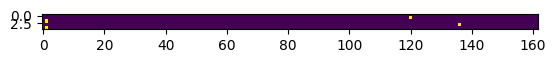

In [220]:
x = test_data[0:1][0].to(device)
y = test_data[0:1][1].to(device)
pred = model(x,y)
pred = torch.softmax(pred,dim=-1)
plt.imshow(pred[0,:5].cpu().detach().numpy())
pred = torch.argmax(pred,dim = -1)
print(pred)
print(CodeDataset.detokensize( pred[0].cpu()))
print(CodeDataset.detokensize( y[0].cpu()))
print(CodeDataset.detokensize( x[0].cpu()))
print(y.cpu(),pred.cpu())
total += (pred == y).sum()
n += len(y)

In [221]:
x = test_data[0:1][0].to(device)
y = test_data[0:1][1].to(device)
print(y.shape)
pred = torch.LongTensor(model.predict(x,y[:,0])).to(device)
#pred = torch.softmax(pred,dim=-1)
#plt.imshow(pred[0,:3].cpu().detach().numpy())
#pred = torch.argmax(pred,dim = -1)
print(CodeDataset.detokensize( pred.cpu()))
print(CodeDataset.detokensize( y[0].cpu()))
print(CodeDataset.detokensize( x[0].cpu()))
print(pred.cpu())
total += (pred == y).sum()
n += len(y)
print(total/n)

torch.Size([1, 128])
[START]public void METHOD_1 ( TYPE_1 VAR_1 ) { if ( ( VAR_1 ) != null ) { VAR_1 . METHOD_2 ( ) ; } } 
[END]
[START]public void METHOD_1 ( TYPE_1 VAR_1 ) { execute ( ( STRING_1 + ( VAR_1 . getId ( ) ) ) ) ; } 
[END]
[START]public void METHOD_1 ( TYPE_1 VAR_1 ) { execute ( ( ( STRING_1 + ( VAR_1 . getId ( ) ) ) + STRING_2 ) ) ; } 
[END]
tensor([161, 120,   1, 136,   1, 153,  64,  18,   1,   9,   1, 155,  64,  18,
          1, 154,  64,  18,   1,  10,   1,  92,   1, 109,   1,   9,   1,   9,
          1, 154,  64,  18,   1,  10,   1,   2,  30,   1,  79,  86,  77,  77,
          1,  10,   1,  92,   1, 154,  64,  18,   1,  15,   1, 153,  64,  19,
          1,   9,   1,  10,   1,  28,   1,  94,   1,  94,   1,  96, 160,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0

## with biLSTM encoder

In [224]:
class biLSTMEncoderDecoder(nn.Module):
    def __init__(self,vocab,max_tokens,embedding_dim,device):
        super().__init__()
        self.emb = Embedder(vocab,embedding_dim)
        self.encoder = LSTMBiEncoder(embedding_dim,64,256,device)
        self.decoder = LSTMDecoder(vocab,embedding_dim,128,512,max_tokens,device)
        self.device = device
        self.embedding_dim = embedding_dim
        self.vocab = vocab
        self.max_tokens = max_tokens
    def forward(self,x,y):
        x = self.emb(x)
        h,c = self.encoder(x)
        y = self.decoder(h,c,self.emb(y))
        return y
    def predict(self,x,y):
        x = self.emb(x)
        h,c = self.encoder(x)[-1]
        outputs = [y]
        y_emb = self.emb(y)
        for i  in range(self.max_tokens-1):
            h,c,y_ = self.decoder.predict_next(h,c,y_emb)
            y = torch.argmax(y_,dim=-1)
            outputs.append(y)
            y_emb = self.emb(y)
        return outputs

In [225]:
import gc
gc.collect()
torch.cuda.empty_cache()

model = biLSTMEncoderDecoder(CodeDataset.getVocab(),128,32,device)
model.to(device)
loss_fn = nn.CrossEntropyLoss()

opt = torch.optim.Adam(model.parameters(),lr = 3e-3)

max_epochs = 30
model.train()
for i in range(max_epochs):
    s = 0
    for (x,y) in train_dataset:
        x = x.to(device)
        y = y.to(device)
        opt.zero_grad()
        pred = model(x,y).transpose(1,2)
        loss = loss_fn(pred,y)
        loss.backward()
        s+=loss.item()
        opt.step()
    if (i%5 == 0):
        with torch.no_grad():
            total = 0
            n = 0
            for (x,y) in valid_dataset:
                x = x.to(device)
                y = y.to(device)
                pred = model(x,y)
                pred2 = torch.argmax(pred,dim = -1)
                total += (pred2 == y).sum()
                n += len(y.reshape(-1))
            print(pred[0])
            print(pred2[0])
            print(y[0])
            print(total/n)

tensor([[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   1.0000],
        [ -3.0275,   7.0474,  -2.8889,  ...,   5.7389,  -5.5868,  -4.9125],
        [ -2.6617,  17.6304,  -4.3799,  ...,   3.0295,  -6.9769,  -5.1466],
        ...,
        [ 32.6503,  -2.5606, -14.1720,  ..., -27.5670, -27.3803, -24.3579],
        [ 32.6942,  -2.6226, -14.1429,  ..., -27.5734, -27.4886, -24.4016],
        [ 32.7379,  -2.6843, -14.1139,  ..., -27.5798, -27.5965, -24.4451]],
       device='cuda:0')
tensor([161, 120,   1, 107,   1, 153,  64,  18,   1,   9,   1,  10,   1,  92,
          1, 125,   1, 154,   1,  28,   1,  94,   1,  96, 160,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 